# DoRA vs LoRA Benchmark Comparison

This notebook compares the evaluation results of two fine-tuning methods applied to **LLaMA 8B**:

- **LoRA** (Low-Rank Adaptation): A popular parameter-efficient fine-tuning method that adds small trainable matrices to frozen model weights.
- **DoRA** (Weight-Decomposed Low-Rank Adaptation): A newer variant that decomposes weights into **magnitude** and **direction** components, then applies low-rank adaptation only to the direction. This often leads to better performance with similar parameter counts.

Both models were evaluated on three standard benchmarks using the `lm-evaluation-harness`:
- **ARC-Easy**: Science questions from grade-school exams (measures reasoning)
- **HellaSwag**: Sentence completion requiring commonsense knowledge
- **WinoGrande**: Pronoun resolution requiring world knowledge

## 1. Load the Results

Each JSON file is the full output from `lm-evaluation-harness`. The key we care about is `"results"`, which contains per-benchmark scores.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the raw JSON files
with open("results_llama_8b_dora.json") as f:
    dora_raw = json.load(f)

with open("results_llama_8b_lora.json") as f:
    lora_raw = json.load(f)

# Extract just the benchmark results
dora_results = dora_raw["results"]
lora_results = lora_raw["results"]

print("Benchmarks evaluated:", list(dora_results.keys()))

Benchmarks evaluated: ['arc_easy', 'hellaswag', 'winogrande']


## 2. Build a Comparison Table

We extract two key metrics per benchmark:
- **acc** (accuracy): The raw accuracy — what fraction of answers the model got right.
- **acc_norm** (normalized accuracy): Accuracy adjusted for answer-length bias. Some benchmarks have answer choices of different lengths, and longer answers get higher likelihood just because they have more tokens. `acc_norm` corrects for this by normalizing by answer length. *Not all benchmarks report this* (WinoGrande doesn't).

We also include the **standard error** (`stderr`) which tells us how uncertain each measurement is — smaller is better.

In [2]:
# Build a structured comparison dataframe
rows = []
for benchmark in dora_results:
    d = dora_results[benchmark]
    l = lora_results[benchmark]
    
    row = {
        "Benchmark": benchmark,
        "DoRA acc": d["acc,none"],
        "LoRA acc": l["acc,none"],
        "Δ acc": d["acc,none"] - l["acc,none"],
    }
    
    # Add normalized accuracy if available (WinoGrande doesn't have it)
    if "acc_norm,none" in d:
        row["DoRA acc_norm"] = d["acc_norm,none"]
        row["LoRA acc_norm"] = l["acc_norm,none"]
        row["Δ acc_norm"] = d["acc_norm,none"] - l["acc_norm,none"]
    
    rows.append(row)

df = pd.DataFrame(rows).set_index("Benchmark")

# Format as percentages for readability
df.style.format("{:.2%}").background_gradient(subset=["Δ acc"], cmap="RdYlGn")

,DoRA acc,LoRA acc,Δ acc,DoRA acc_norm,LoRA acc_norm,Δ acc_norm
Benchmark,,,,,,
arc_easy,80.43%,79.92%,0.51%,79.97%,79.34%,0.63%
hellaswag,59.39%,60.01%,-0.62%,78.50%,79.15%,-0.65%
winogrande,76.64%,75.77%,0.87%,nan%,nan%,nan%


## 3. Visual Comparison: Accuracy by Benchmark

A grouped bar chart makes it easy to see which method wins on each benchmark. Error bars show the standard error — if the bars overlap within the error range, the difference isn't statistically meaningful.

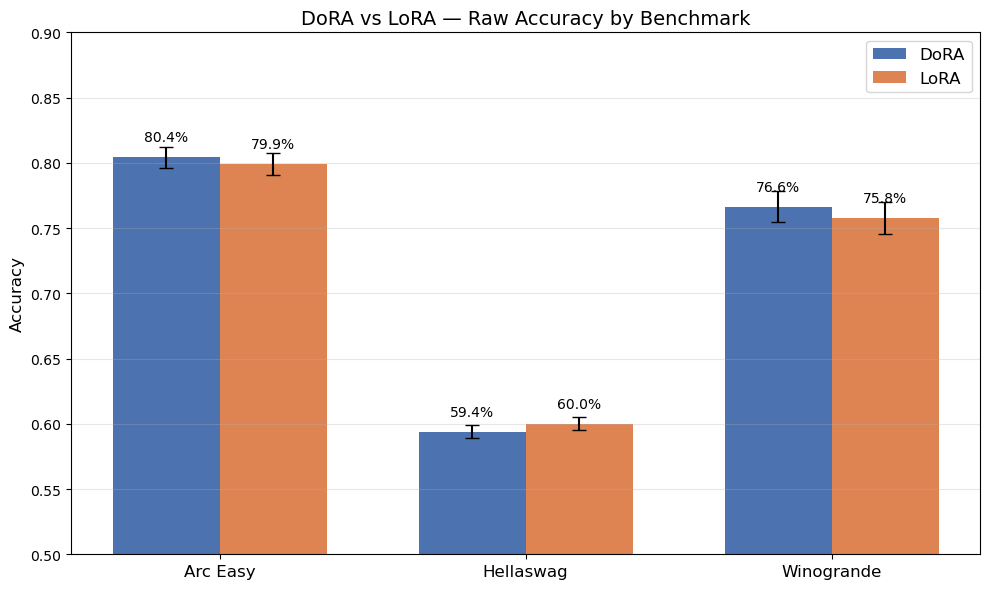

In [3]:
benchmarks = list(dora_results.keys())
dora_acc = [dora_results[b]["acc,none"] for b in benchmarks]
lora_acc = [lora_results[b]["acc,none"] for b in benchmarks]
dora_err = [dora_results[b]["acc_stderr,none"] for b in benchmarks]
lora_err = [lora_results[b]["acc_stderr,none"] for b in benchmarks]

x = np.arange(len(benchmarks))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, dora_acc, width, yerr=dora_err, label="DoRA", capsize=5, color="#4C72B0")
bars2 = ax.bar(x + width/2, lora_acc, width, yerr=lora_err, label="LoRA", capsize=5, color="#DD8452")

ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("DoRA vs LoRA — Raw Accuracy by Benchmark", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([b.replace("_", " ").title() for b in benchmarks], fontsize=12)
ax.legend(fontsize=12)
ax.set_ylim(0.5, 0.9)  # Zoom in to see differences clearly
ax.grid(axis="y", alpha=0.3)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.1%}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

## 4. Normalized Accuracy Comparison

For benchmarks that provide it, `acc_norm` is often considered the **more reliable metric** because it removes the bias toward longer answer choices. Let's compare those too.

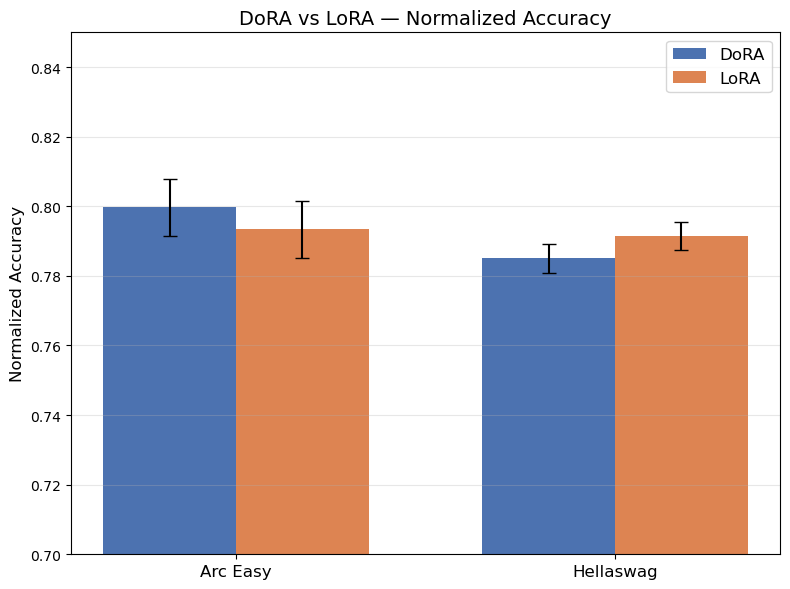

In [4]:
# Only benchmarks with acc_norm
norm_benchmarks = [b for b in benchmarks if "acc_norm,none" in dora_results[b]]
dora_norm = [dora_results[b]["acc_norm,none"] for b in norm_benchmarks]
lora_norm = [lora_results[b]["acc_norm,none"] for b in norm_benchmarks]
dora_norm_err = [dora_results[b]["acc_norm_stderr,none"] for b in norm_benchmarks]
lora_norm_err = [lora_results[b]["acc_norm_stderr,none"] for b in norm_benchmarks]

x = np.arange(len(norm_benchmarks))

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width/2, dora_norm, width, yerr=dora_norm_err, label="DoRA", capsize=5, color="#4C72B0")
ax.bar(x + width/2, lora_norm, width, yerr=lora_norm_err, label="LoRA", capsize=5, color="#DD8452")

ax.set_ylabel("Normalized Accuracy", fontsize=12)
ax.set_title("DoRA vs LoRA — Normalized Accuracy", fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([b.replace("_", " ").title() for b in norm_benchmarks], fontsize=12)
ax.legend(fontsize=12)
ax.set_ylim(0.7, 0.85)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Difference Plot (DoRA − LoRA)

This plot shows the **accuracy difference** (DoRA minus LoRA) for each benchmark. Positive values (green) mean DoRA is better; negative values (red) mean LoRA is better.

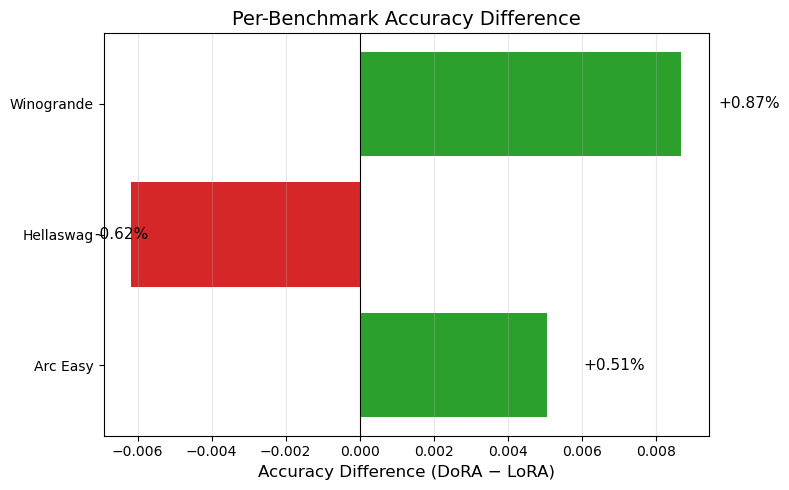

In [5]:
diffs = [dora_results[b]["acc,none"] - lora_results[b]["acc,none"] for b in benchmarks]
colors = ["#2ca02c" if d > 0 else "#d62728" for d in diffs]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh([b.replace("_", " ").title() for b in benchmarks], diffs, color=colors)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Accuracy Difference (DoRA − LoRA)", fontsize=12)
ax.set_title("Per-Benchmark Accuracy Difference", fontsize=14)

# Add value labels
for bar, val in zip(bars, diffs):
    ax.text(val + 0.001 * (1 if val >= 0 else -1), bar.get_y() + bar.get_height()/2,
            f"{val:+.2%}", va="center", fontsize=11)

ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Summary & Takeaways

Let's compute an overall summary to see which method comes out ahead.

In [6]:
avg_dora = np.mean([dora_results[b]["acc,none"] for b in benchmarks])
avg_lora = np.mean([lora_results[b]["acc,none"] for b in benchmarks])

print("=" * 50)
print("AVERAGE ACCURACY ACROSS ALL BENCHMARKS")
print("=" * 50)
print(f"  DoRA:  {avg_dora:.2%}")
print(f"  LoRA:  {avg_lora:.2%}")
print(f"  Diff:  {avg_dora - avg_lora:+.2%}")
print()

# Per-benchmark winner
print("Per-benchmark winner:")
for b in benchmarks:
    d = dora_results[b]["acc,none"]
    l = lora_results[b]["acc,none"]
    winner = "DoRA" if d > l else "LoRA" if l > d else "Tie"
    print(f"  {b:15s}  DoRA={d:.2%}  LoRA={l:.2%}  → {winner} ({abs(d-l):+.2%})")

print()
print("Note: Small differences (< 1%) may not be statistically significant.")
print("Check the error bars in the plots above to judge significance.")

AVERAGE ACCURACY ACROSS ALL BENCHMARKS
  DoRA:  72.15%
  LoRA:  71.90%
  Diff:  +0.25%

Per-benchmark winner:
  arc_easy         DoRA=80.43%  LoRA=79.92%  → DoRA (+0.51%)
  hellaswag        DoRA=59.39%  LoRA=60.01%  → LoRA (+0.62%)
  winogrande       DoRA=76.64%  LoRA=75.77%  → DoRA (+0.87%)

Note: Small differences (< 1%) may not be statistically significant.
Check the error bars in the plots above to judge significance.


## Key Concepts Recap

| Term | Meaning |
|---|---|
| **LoRA** | Adds low-rank trainable matrices (A×B) to frozen weights. Only trains A and B. |
| **DoRA** | Decomposes weight into magnitude (m) and direction (V/‖V‖), then applies LoRA to the direction only. Trains m + A + B. |
| **acc** | Raw accuracy — fraction of correct answers. |
| **acc_norm** | Length-normalized accuracy — corrects for bias toward longer answer choices. |
| **stderr** | Standard error — measures uncertainty. Smaller = more confident measurement. |
| **ARC-Easy** | Grade-school science questions (AI2 Reasoning Challenge). |
| **HellaSwag** | Commonsense sentence completion. |
| **WinoGrande** | Pronoun disambiguation requiring world knowledge. |

In [ ]:
import torch
import os
from transformers import AutoModelForCausalLM
from peft import PeftModel

os.makedirs("figures", exist_ok=True)

# ── Configuration ──────────────────────────────────────────────────
BASE_MODEL_ID = "Qwen/Qwen2.5-1.5B"
LORA_ADAPTER_PATH = "./qwen2.5-1.5b-lora-commonsense/final_adapter"
DORA_ADAPTER_PATH = "./qwen2.5-1.5b-dora-commonsense/final_adapter"

# Target modules to analyze (must match your LoRA config)
TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "up_proj", "down_proj"]

In [ ]:
import torch
from transformers import AutoModelForCausalLM
from peft import PeftModel

# ── Configuration ──────────────────────────────────────────────────
BASE_MODEL_ID = "Qwen/Qwen2.5-1.5B"
LORA_ADAPTER_PATH = "./qwen2.5-1.5b-lora-commonsense/final_adapter"
DORA_ADAPTER_PATH = "./qwen2.5-1.5b-dora-commonsense/final_adapter"

# Target modules to analyze (must match your LoRA config)
TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "up_proj", "down_proj"]

In [ ]:
def load_and_merge(base_model_id, adapter_path):
    """Load base model, apply adapter, merge, and return state_dict."""
    base = AutoModelForCausalLM.from_pretrained(
        base_model_id, torch_dtype=torch.float32, device_map="cpu"
    )
    model = PeftModel.from_pretrained(base, adapter_path)
    merged = model.merge_and_unload()
    return {k: v.clone() for k, v in merged.state_dict().items()}


def get_base_weights(base_model_id):
    """Load base model weights."""
    base = AutoModelForCausalLM.from_pretrained(
        base_model_id, torch_dtype=torch.float32, device_map="cpu"
    )
    return {k: v.clone() for k, v in base.state_dict().items()}


print("Loading base model weights...")
base_weights = get_base_weights(BASE_MODEL_ID)

print("Loading and merging LoRA adapter...")
lora_weights = load_and_merge(BASE_MODEL_ID, LORA_ADAPTER_PATH)

print("Loading and merging DoRA adapter...")
dora_weights = load_and_merge(BASE_MODEL_ID, DORA_ADAPTER_PATH)

print("All models loaded.")

In [ ]:
def compute_delta_m_delta_d(w_base, w_ft):
    """
    Decompose weight change into magnitude (ΔM) and direction (ΔD) components.
    
    For a weight matrix W (out_features x in_features):
      - Magnitude: column-wise L2 norm → M = ||W||_col
      - Direction: D = W / M (unit-norm columns)
      - ΔM = mean |M_ft - M_base| / mean(M_base)  (relative magnitude change)
      - ΔD = mean cosine distance between direction columns
    """
    # Column-wise norms (each column is one "neuron direction")
    m_base = torch.norm(w_base, dim=0)
    m_ft = torch.norm(w_ft, dim=0)
    
    # Relative magnitude change
    delta_m = torch.mean(torch.abs(m_ft - m_base) / (m_base + 1e-8)).item()
    
    # Direction vectors (normalize columns)
    d_base = w_base / (m_base.unsqueeze(0) + 1e-8)
    d_ft = w_ft / (m_ft.unsqueeze(0) + 1e-8)
    
    # Cosine distance per column: 1 - cos_sim
    cos_sim = torch.sum(d_base * d_ft, dim=0).clamp(-1, 1)
    delta_d = torch.mean(1 - cos_sim).item()
    
    return delta_m, delta_d


# Compute ΔM and ΔD for every target layer
records = []

for key in base_weights:
    # Match target modules
    if not any(t in key for t in TARGET_MODULES):
        continue
    if not key.endswith(".weight"):
        continue
    
    w_base = base_weights[key]
    
    if key in lora_weights:
        dm_lora, dd_lora = compute_delta_m_delta_d(w_base, lora_weights[key])
        records.append({
            "layer": key.replace("model.layers.", "L").replace(".self_attn.", ".").replace(".mlp.", "."),
            "method": "QLoRA",
            "ΔM": dm_lora,
            "ΔD": dd_lora,
        })
    
    if key in dora_weights:
        dm_dora, dd_dora = compute_delta_m_delta_d(w_base, dora_weights[key])
        records.append({
            "layer": key.replace("model.layers.", "L").replace(".self_attn.", ".").replace(".mlp.", "."),
            "method": "QDoRA",
            "ΔM": dm_dora,
            "ΔD": dd_dora,
        })

df_mech = pd.DataFrame(records)
print(f"Computed ΔM/ΔD for {len(df_mech)} layer×method combinations")
df_mech.head(10)

### 7.1 ΔM vs ΔD Scatter Plot

Each point is one target layer. If DoRA's decomposition works as intended, its points should show **larger ΔM** (magnitude absorbs the update) and **smaller ΔD** (direction stays closer to pretrained) compared to LoRA.

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

for method, color, marker in [("QLoRA", "#DD8452", "o"), ("QDoRA", "#4C72B0", "s")]:
    subset = df_mech[df_mech["method"] == method]
    ax.scatter(subset["ΔD"], subset["ΔM"], c=color, marker=marker,
               s=60, alpha=0.7, edgecolors="white", linewidth=0.5, label=method)

ax.set_xlabel("ΔD (Direction Change — Cosine Distance)", fontsize=13)
ax.set_ylabel("ΔM (Relative Magnitude Change)", fontsize=13)
ax.set_title("Mechanistic Decomposition: ΔM vs ΔD per Layer", fontsize=14)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/delta_m_vs_delta_d.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved to figures/delta_m_vs_delta_d.png")

### 7.2 Per-Module Breakdown

Breaking down ΔM and ΔD by module type (q_proj, k_proj, etc.) reveals which components each method adapts most aggressively.

In [ ]:
# Extract module type from layer name
def get_module_type(layer_name):
    for m in TARGET_MODULES:
        if m in layer_name:
            return m
    return "other"

df_mech["module"] = df_mech["layer"].apply(get_module_type)

# Summary table: mean ΔM and ΔD per method × module
summary = df_mech.groupby(["method", "module"])[["ΔM", "ΔD"]].mean().round(6)
print(summary)
print()

# Overall summary
overall = df_mech.groupby("method")[["ΔM", "ΔD"]].agg(["mean", "std"]).round(6)
print("Overall summary:")
print(overall)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(axes, ["ΔM", "ΔD"], 
                               ["Relative Magnitude Change (ΔM)", "Direction Change (ΔD)"]):
    pivot = df_mech.groupby(["module", "method"])[metric].mean().unstack("method")
    pivot.plot(kind="bar", ax=ax, color={"QLoRA": "#DD8452", "QDoRA": "#4C72B0"}, 
               edgecolor="white", width=0.7)
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=11)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("figures/delta_per_module.png", dpi=150, bbox_inches="tight")
plt.show()

### 7.3 Layer-wise ΔM and ΔD Across Depth

Visualizing how magnitude and direction changes evolve across transformer layers reveals whether the adaptation strategy differs in early vs. late layers.

In [ ]:
# Extract layer index from name
import re

def get_layer_idx(name):
    match = re.search(r'L(\d+)', name)
    return int(match.group(1)) if match else -1

df_mech["layer_idx"] = df_mech["layer"].apply(get_layer_idx)

# Average ΔM and ΔD across modules for each layer depth
layer_avg = df_mech.groupby(["layer_idx", "method"])[["ΔM", "ΔD"]].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, title in zip(axes, ["ΔM", "ΔD"],
                               ["ΔM Across Layers", "ΔD Across Layers"]):
    for method, color in [("QLoRA", "#DD8452"), ("QDoRA", "#4C72B0")]:
        sub = layer_avg[layer_avg["method"] == method].sort_values("layer_idx")
        ax.plot(sub["layer_idx"], sub[metric], marker="o", markersize=4,
                color=color, label=method, alpha=0.8)
    ax.set_xlabel("Layer Index", fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("figures/delta_by_layer_depth.png", dpi=150, bbox_inches="tight")
plt.show()